**Task**

1. Accept a user's name, age, adn a list of their skills
2. Pass the state through three nodes that:
    * First node: Personalizes the name field with a greeting
    * Second node: Describe the user's age
    * Third node: Lists the user's skills in a formatted string.

3. Final output in the result field should be a combined message in this format:

output: "Linda, welcome to the system! You are 31 years old! You have skills in: python, Machine Learning, and LangGraph"

**Hint:** You will need to use the add_edge method twice

In [6]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [ ]:
#create the state schema
class AgentState(TypedDict):
    name: str
    age:int
    skills:List[str]
    final:str

In [9]:
#first node
def greeting(state:AgentState)->AgentState:
    """Greet the user"""
    state['final']=f"{state['name']}, welcome to the system!"

    return state

#second node
def age_description(state: AgentState)->AgentState:
    """Describe the Age"""

    state['final']=state['final']+f" You are {state['age']} years old.😎"

    return state

#third node
def user_actions(state: AgentState)->AgentState:
    """Skills they can do"""
    
    state['final']=state['final']+f" You have skills in: {state['skills']}"

    return state



In [11]:
#Create the graph
graph=StateGraph(AgentState)

#add nodes
graph.add_node('greeting',greeting)
graph.add_node('age_descrip', age_description)
graph.add_node('user_actions', user_actions)

#start the graph
graph.set_entry_point('greeting')

#Connect the nodes together
graph.add_edge('greeting','age_descrip')
graph.add_edge('age_descrip','user_actions')

#END the graph
graph.set_finish_point('user_actions')

#compile graph
app=graph.compile()

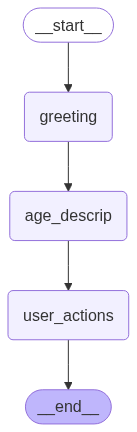

In [12]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [13]:
while True:
    name=input("Enter name: ")
    age=input("Age:")
    skills=input("SKILLS: ")
    
    result=app.invoke({"name":name,"age":age,"skills":skills})

    print(result['final'])

    print()
    proceeed=input("Do wish to continue? ")

    if proceeed=='yes':
        continue
    else:
        break


Allan, welcome to the system! You are 25 years old.😎 You have skills in: AI CyberSEc Programing



In [14]:
result=app.invoke({"name":"Linda","age":31,"skills":"Python, Machine Learning and LangGraph"})

In [15]:
result['final']

'Linda, welcome to the system! You are 31 years old.😎 You have skills in: Python, Machine Learning and LangGraph'